In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv('creditcard.csv')
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
246814,153340.0,-0.393339,0.023950,-1.280069,-1.610818,0.215156,-1.203840,0.375806,0.131576,0.690269,...,0.298968,0.898856,0.479474,0.616830,-0.543237,0.659045,-0.336804,-0.079964,43.70,0
265142,161756.0,-0.950291,-0.493491,1.391326,1.124501,-0.875356,2.060137,-1.510840,-2.123820,0.015447,...,-0.891271,0.659991,-0.667134,0.073032,1.219134,-0.234990,0.029915,0.248138,352.50,0
101683,67915.0,1.531935,-1.035455,0.115123,-1.627760,-1.109800,-0.237894,-1.039275,-0.042114,-2.022797,...,-0.218092,-0.277143,-0.079235,-0.524720,0.461143,-0.171924,0.023724,0.002270,15.00,0
197755,132163.0,2.061713,-0.012144,-1.050097,0.413563,-0.101259,-1.206437,0.221051,-0.365707,0.460770,...,-0.282485,-0.654205,0.334803,0.060809,-0.281736,0.193590,-0.067297,-0.058678,1.98,0
149350,91066.0,0.189442,1.338625,-0.303639,0.026598,0.858430,-1.323577,1.021076,-0.441249,1.072836,...,0.125750,0.946997,-0.210865,-0.040239,-0.301879,-0.185085,0.372482,0.187515,2.36,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.duplicated().sum()  #1081

# Droping Duplicates
df = df.drop_duplicates()

In [7]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.Class.unique() # Only Target Col is categorical with 2 records

array([0, 1], dtype=int64)

# Basic Cleaning:-

In [9]:
# Taking Hour instead of Seconds:- Time from First Transaction from 0 to 23 Hours.
df['Hour'] = (df['Time']//3600)%24
# Drop Existing Coolumn:-
df = df.drop(columns='Time',axis=1)

# Exploratory Data Analysis

In [14]:
print(f'Distribution Of Target Feature:- \n{df['Class'].value_counts(Normalize=True)}')

# PLot


TypeError: IndexOpsMixin.value_counts() got an unexpected keyword argument 'Normalize'

<Axes: xlabel='Class', ylabel='count'>

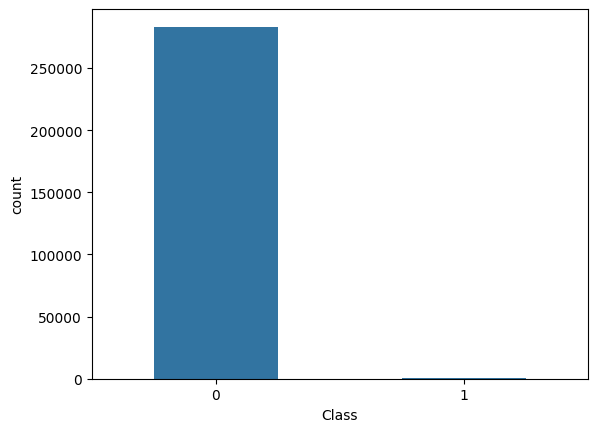

In [11]:
sns.countplot(x='Class',data=df,width=0.5)

In [12]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class',
       'Hour'],
      dtype='object')

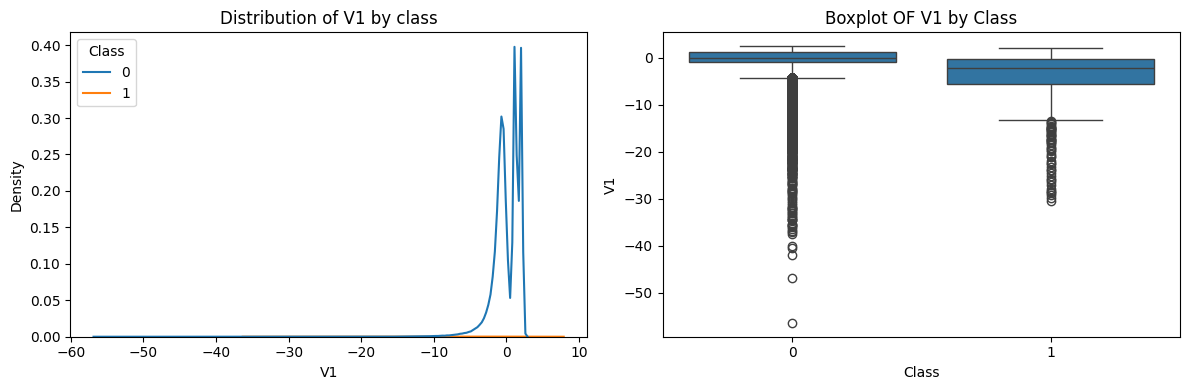

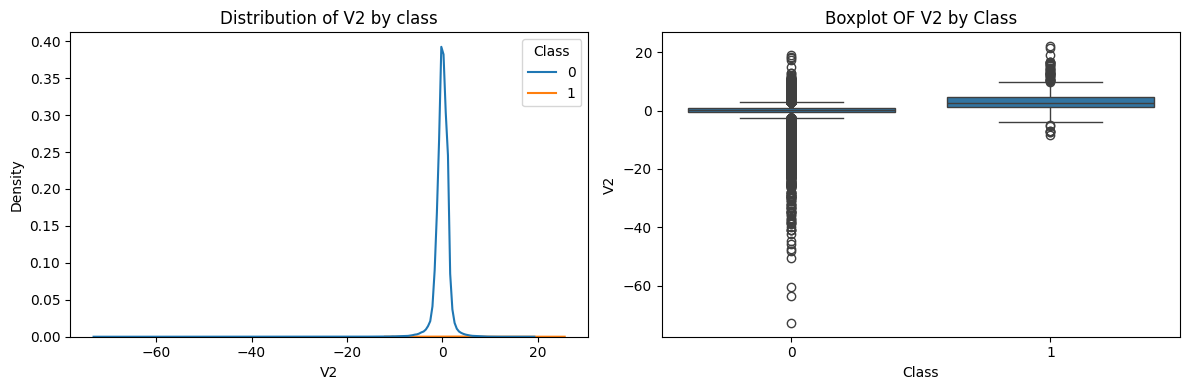

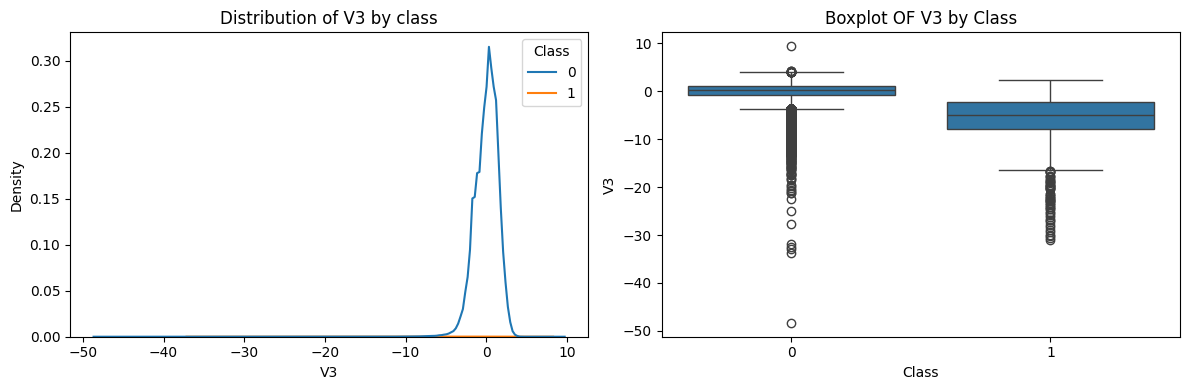

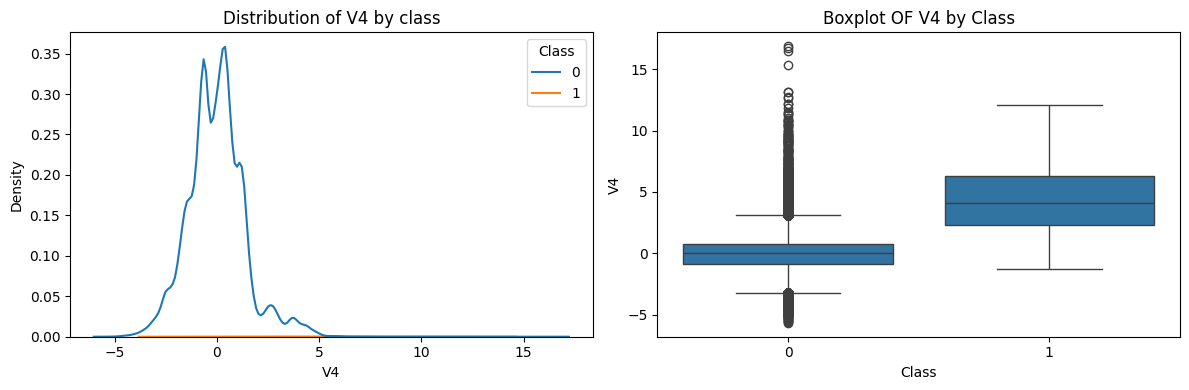

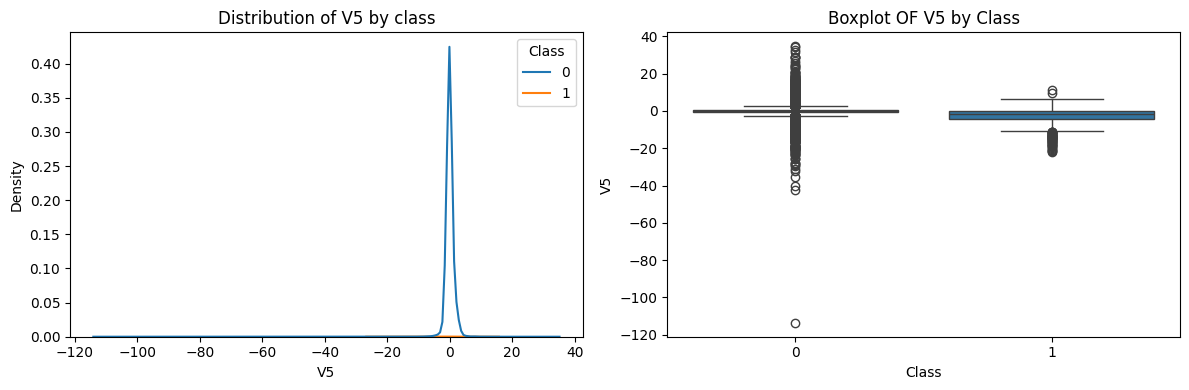

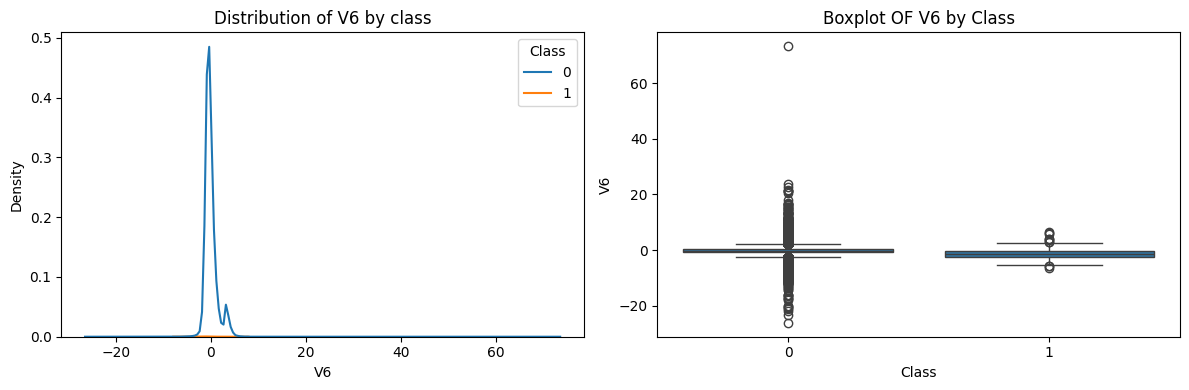

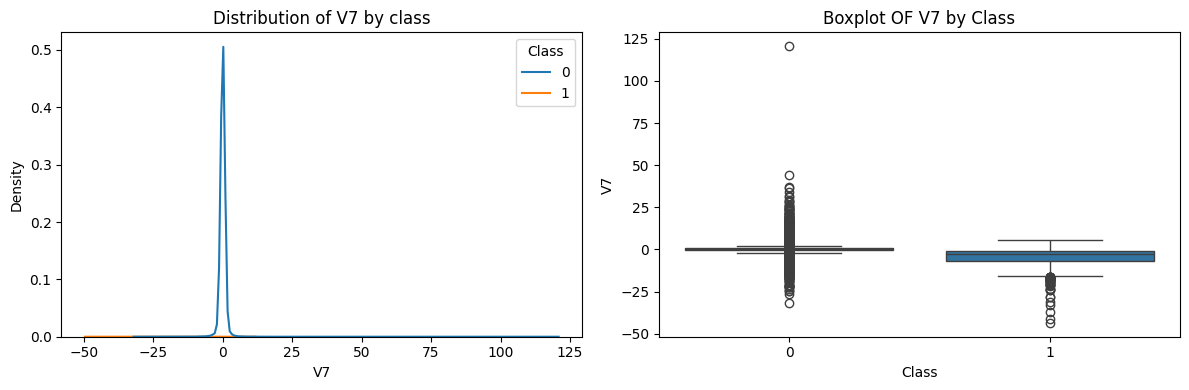

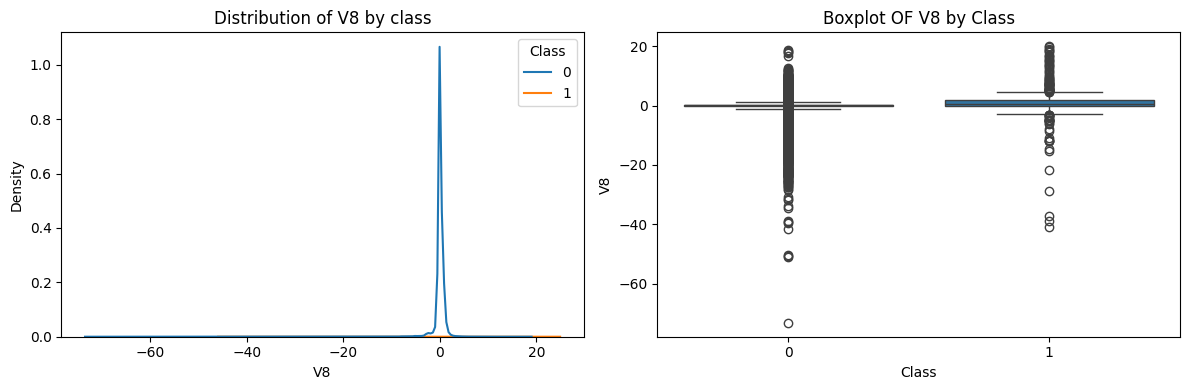

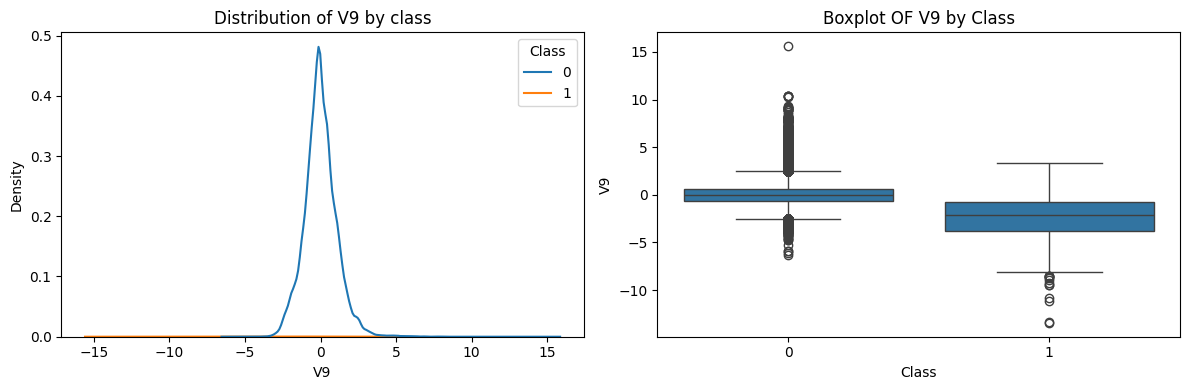

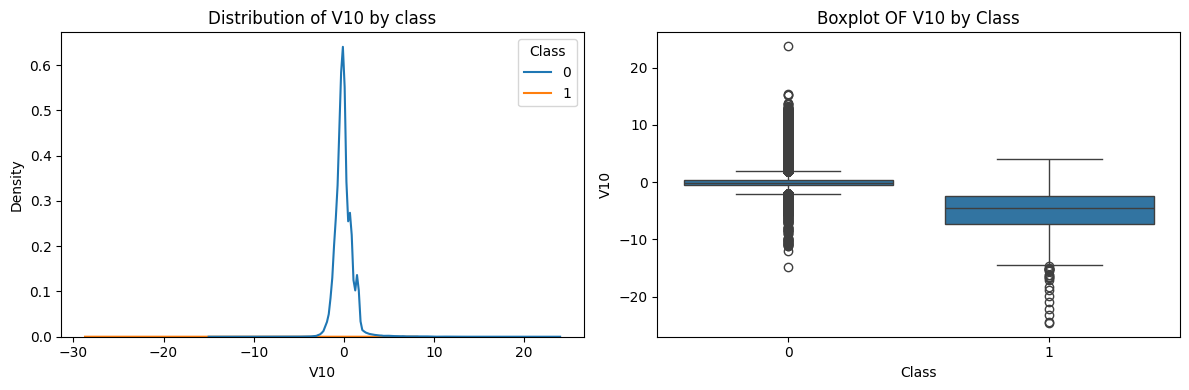

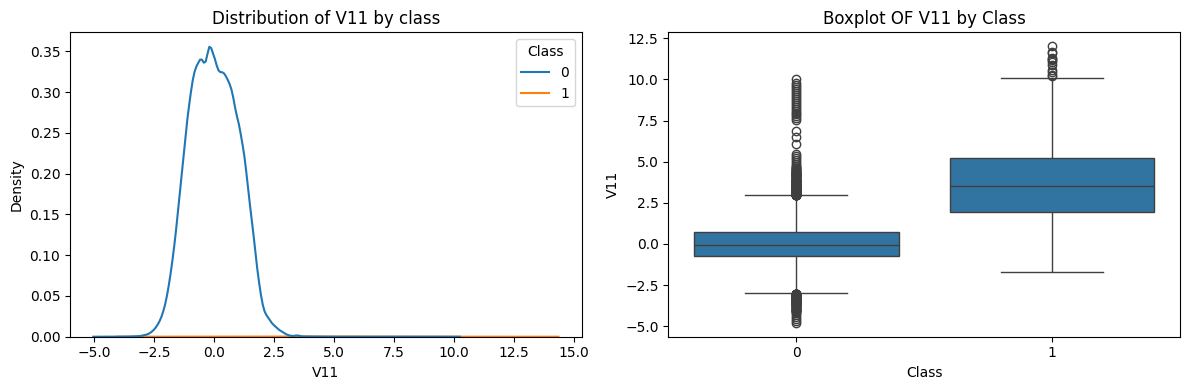

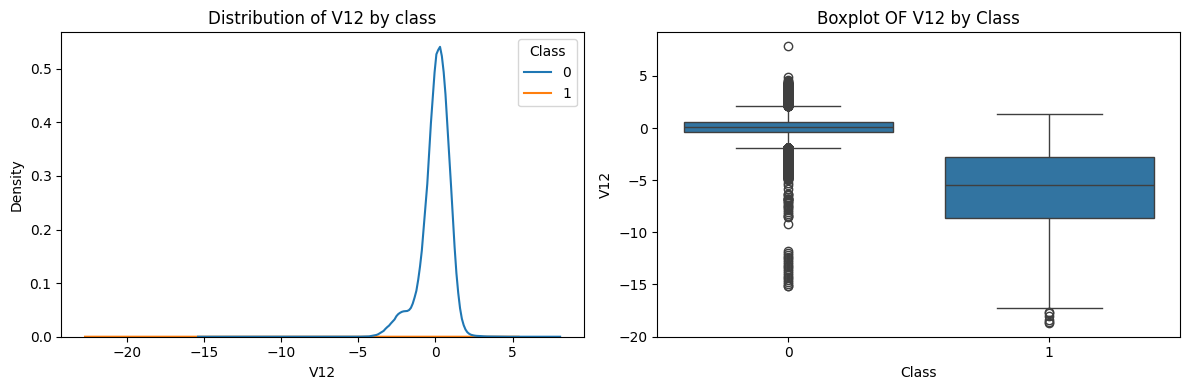

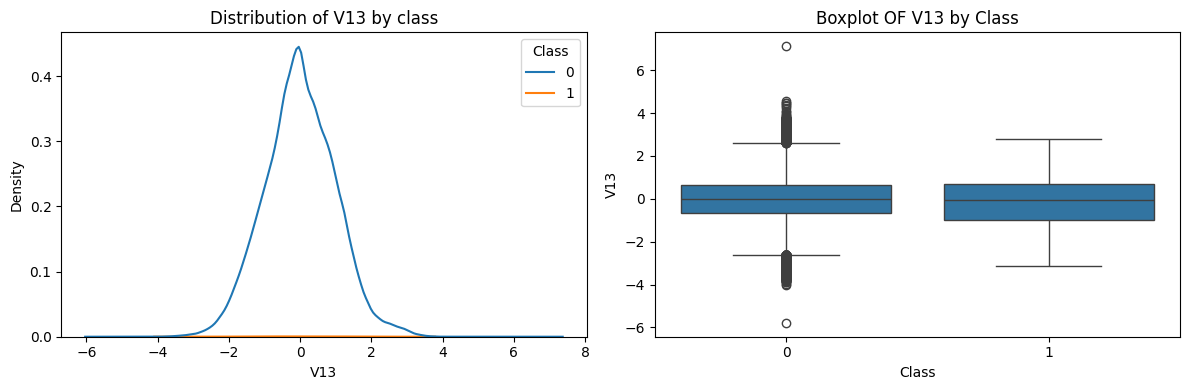

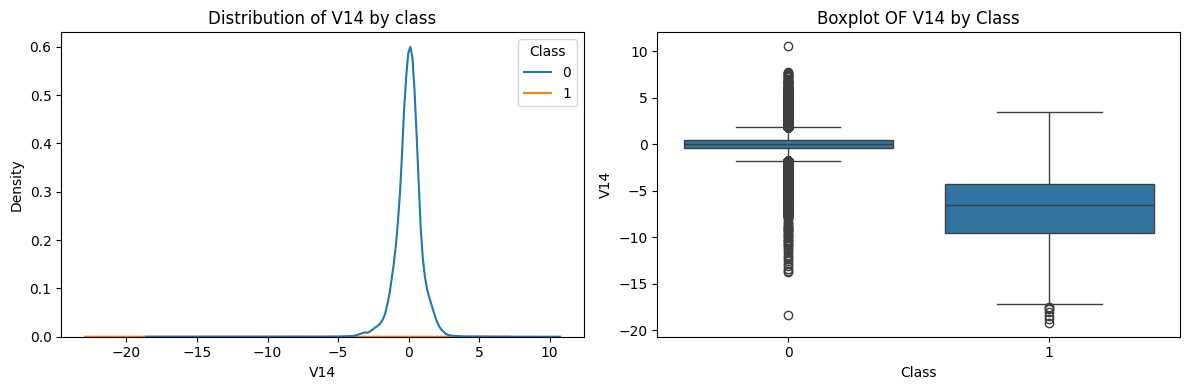

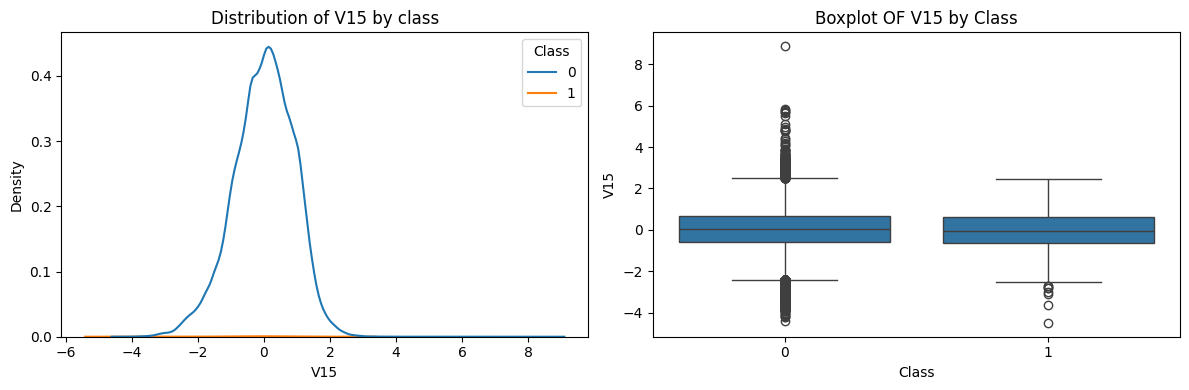

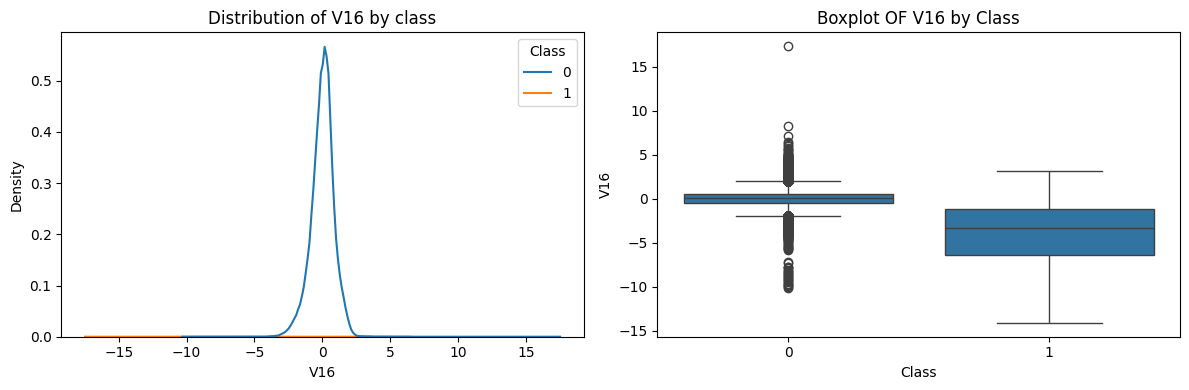

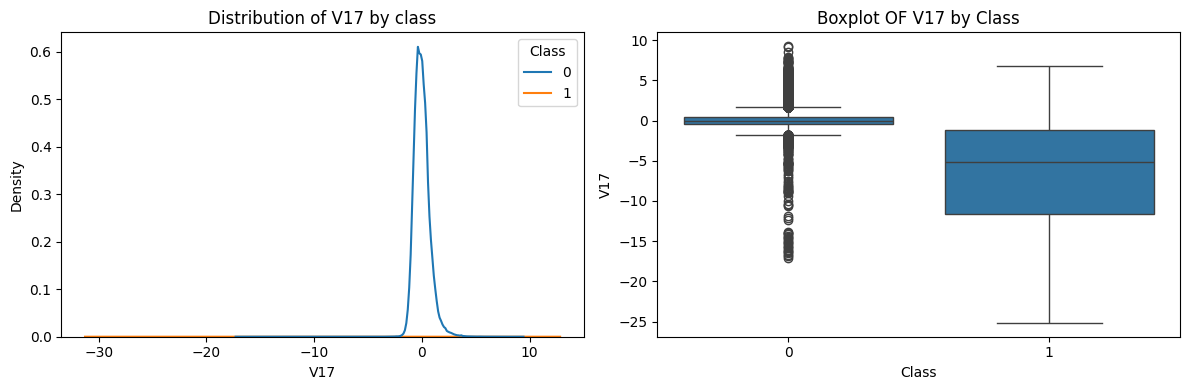

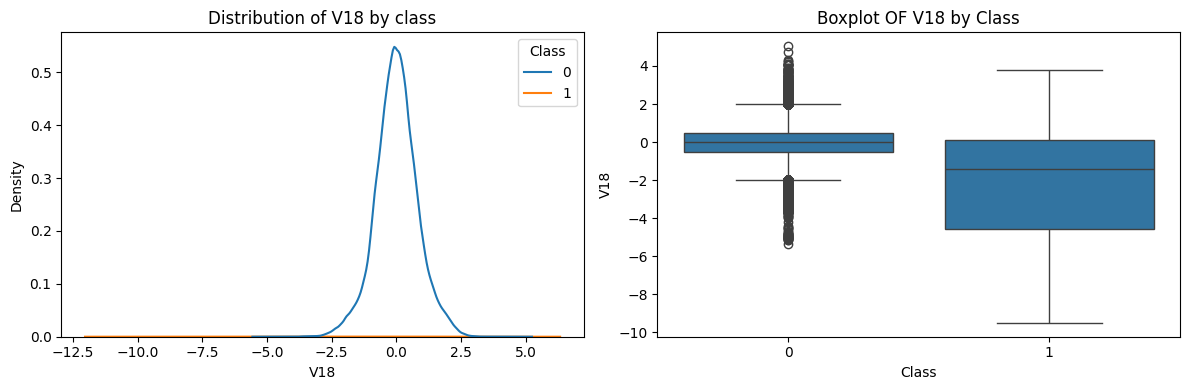

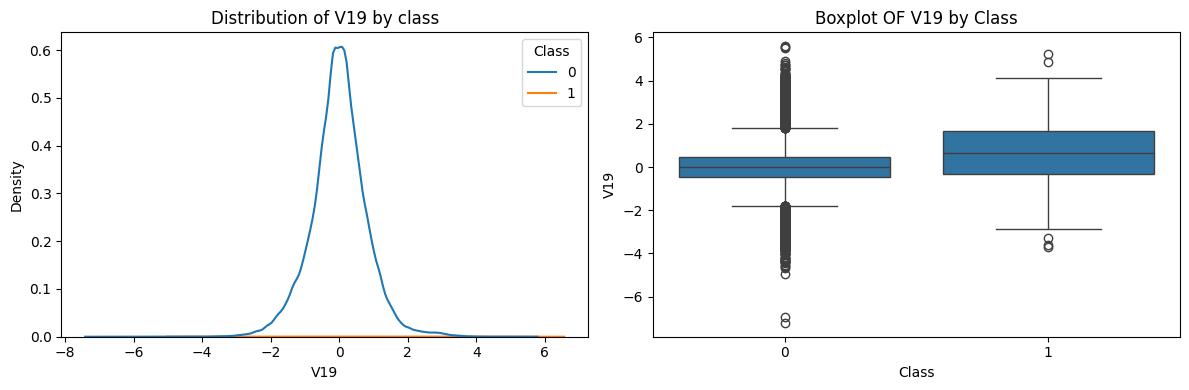

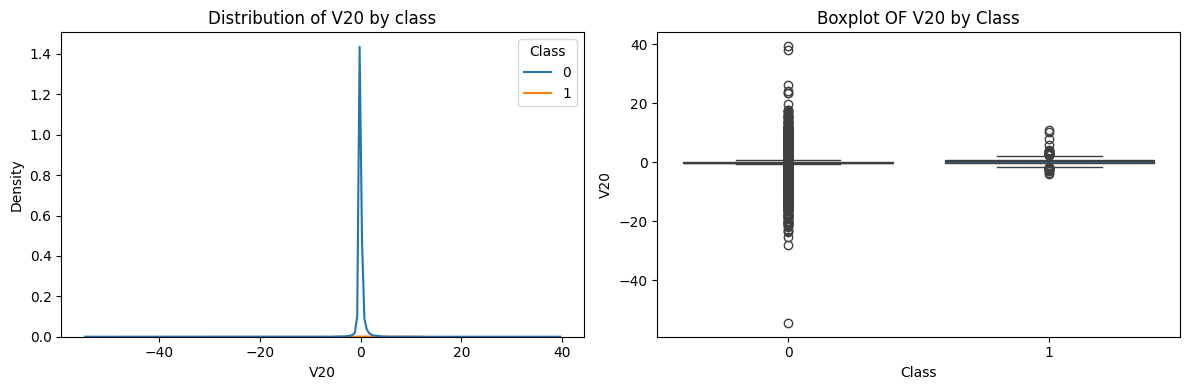

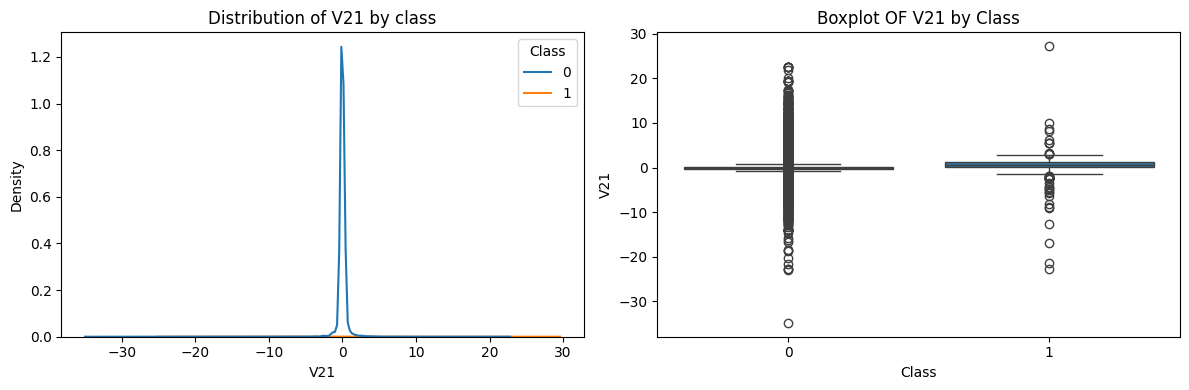

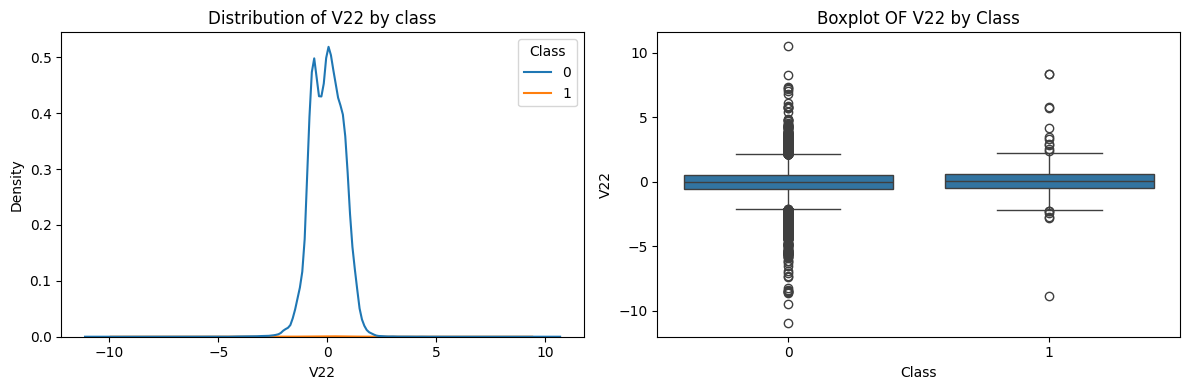

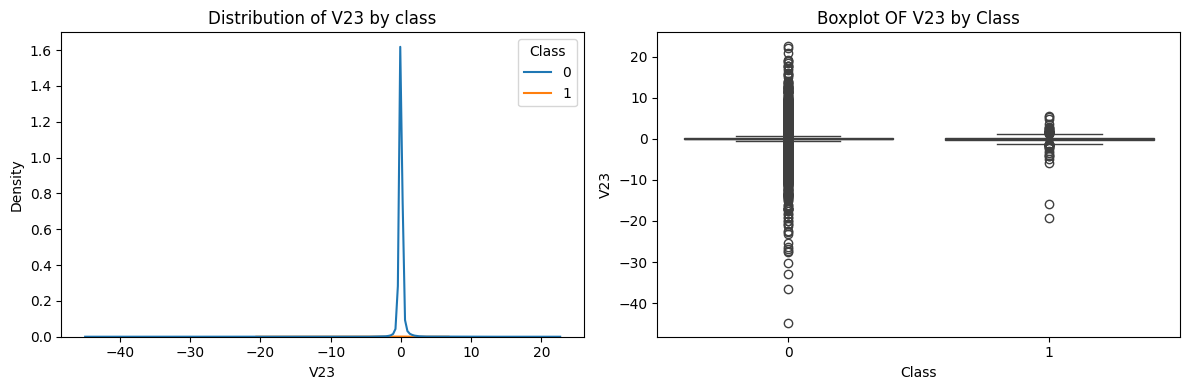

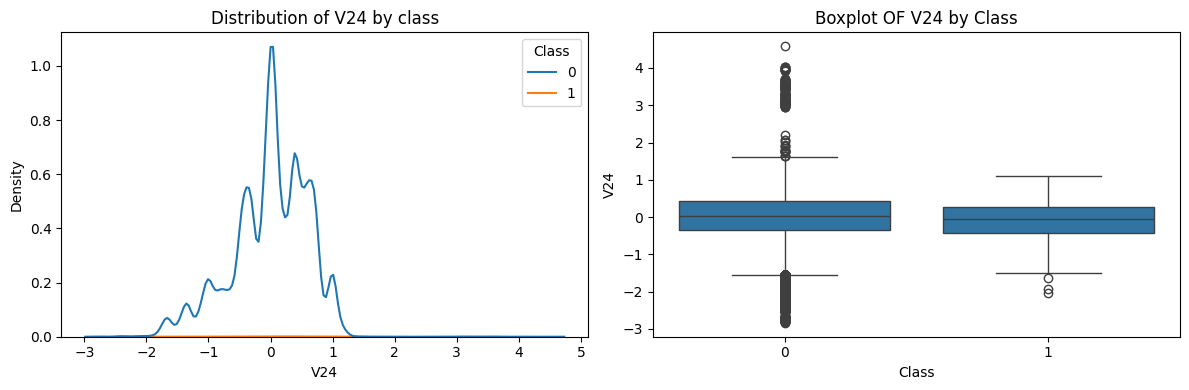

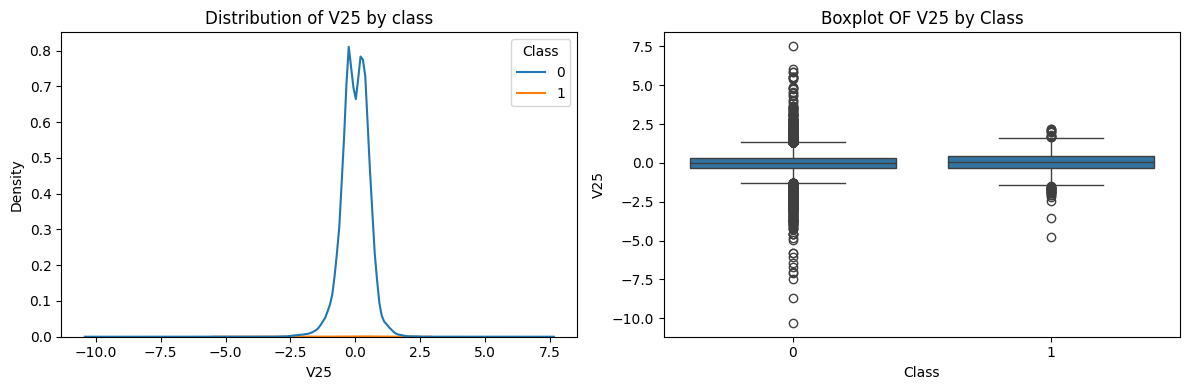

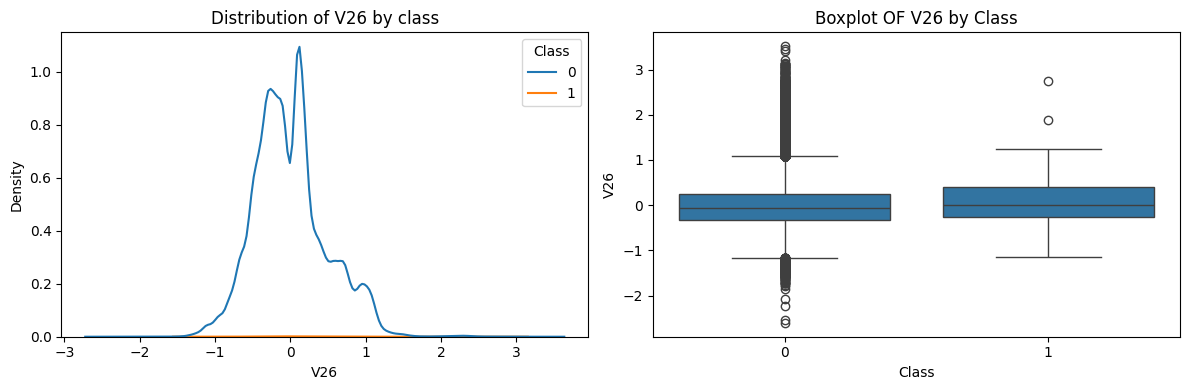

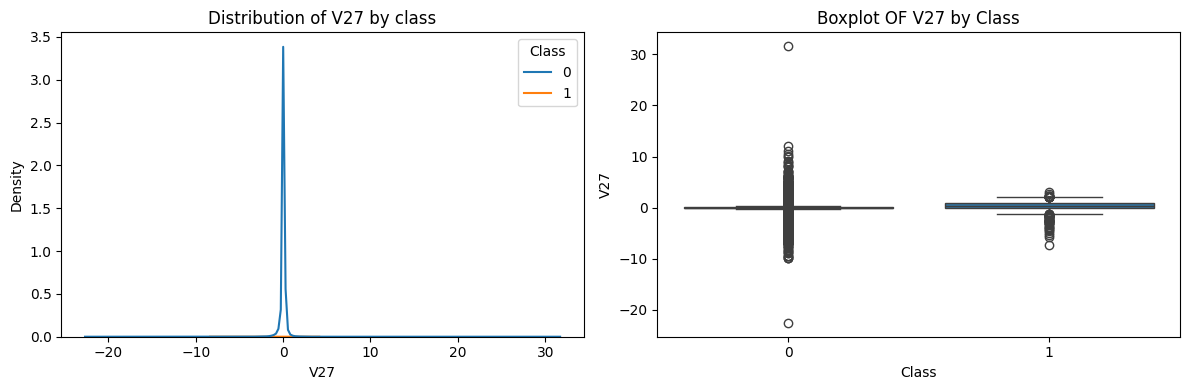

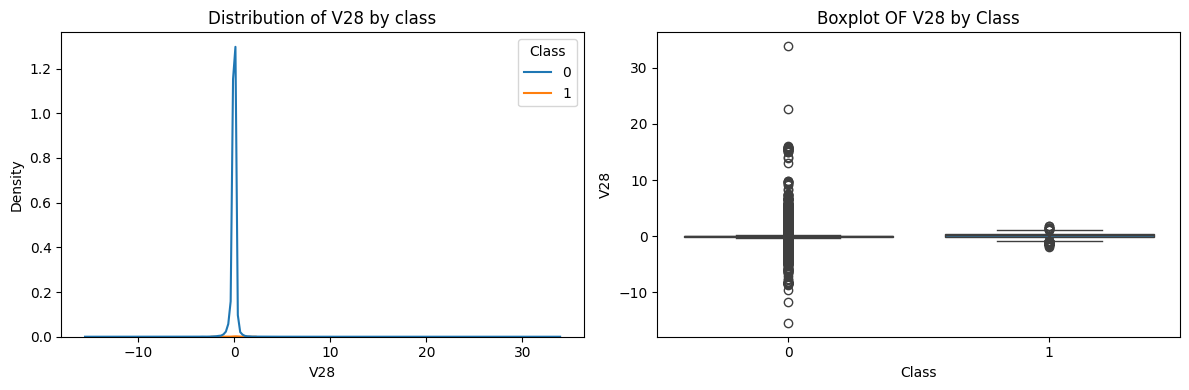

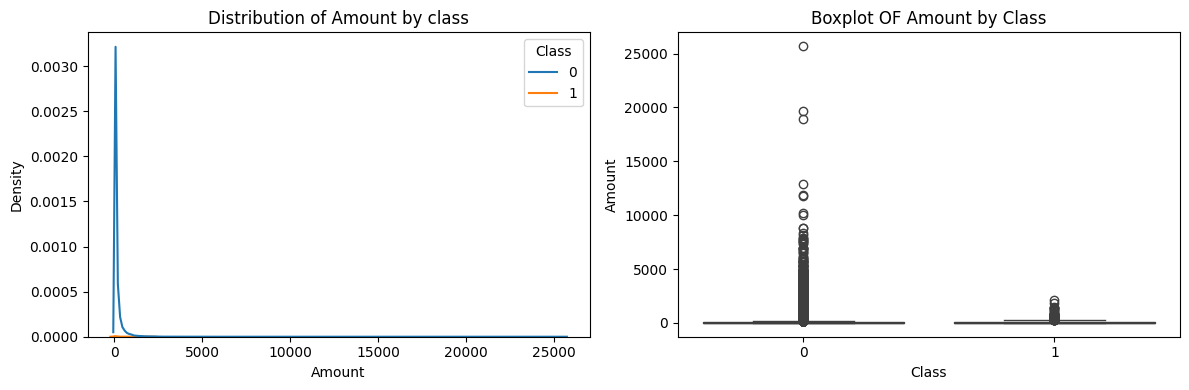

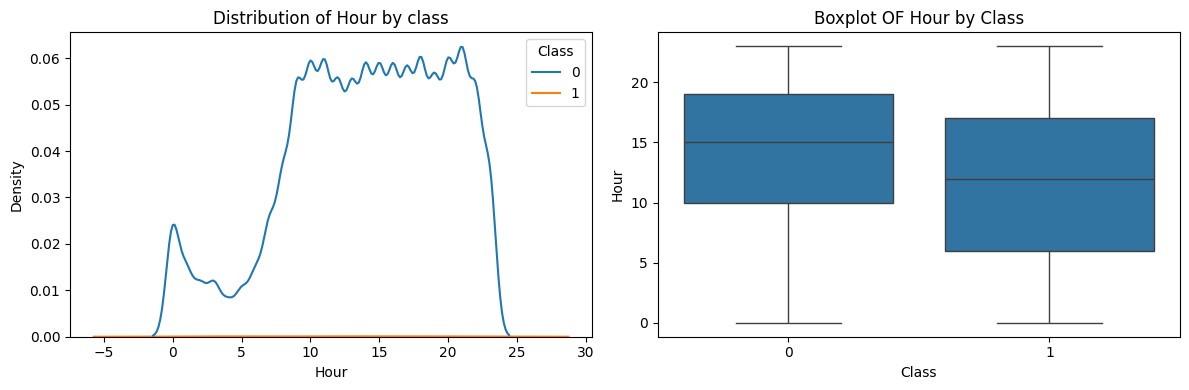

In [13]:
num_cols=['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Hour']
for col in num_cols:
    fig,ax = plt.subplots(1,2,figsize=(12,4))
    # Distribution plot
    sns.kdeplot(data=df,x=col,hue='Class',ax=ax[0])
    ax[0].set_title(f'Distribution of {col} by class')

    # Box plot
    sns.boxplot(data=df,x='Class',y=col ,ax=ax[1])
    ax[1].set_title(f'Boxplot OF {col} by Class')

    plt.tight_layout()
    plt.show()

In [ ]:
!pip install jupyter_contrib_nbextensions
!jupyter contrib nbextension install --user